# Caso: Tanque 1 entrada e 1 saída
Objetivo: Modelo para controle de tanque. O sistema contém 1 válvula de entrada e 1 válvula de saída para regular a vazão.

Premissa: Apenas a válvula de saída estará em malha fechada.

Dados:
k1 = 0.05 m^3/s
a1 = 0.6 (abertura da válvula)
k2 = 0.015 m^2
a2 = 0.5 (abertura válvua de saída)
A = 0.5 m^2 (área seção transversal tanque)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import control as ct
import sympy as sp

## 1 Modelagem e linearização

Balanço de massa do sistema:
$$F_0 - F_s = A \times h$$

Balanço de energia entre entrada (atmosférica) e saída:
$$E_c = \frac{1mv^2}{2}$$
$$E_g = m \times g \times h$$

Saída do sistema: $v = \sqrt{2 \times g \times h}\ [\mathrm{m/s}]$

Assim,

$$\frac{dh}{dt} = \frac{k_1 a_1}{A} - \frac{k_2 a_2 \sqrt{2 \times g \times h}}{A}$$

O estado estacionário é dado por:

$$0 = \frac{k_1 a_1}{A} - \frac{k_2 a_2 \sqrt{2 \times g \times h}}{A}$$

Substituindo os valores dos parâmetros: $H_0 = 0.815\ \mathrm{[m]}$

A linearização do sistema passa a avaliar $\frac{dh}{dt} = f(a_1, a_2, h)$

Manipulando:
$$\frac{d \bar{h}}{dt} = \biggl[\frac{\partial f}{\partial a_1} \biggl]_s \bar{A}_1 + \biggl[\frac{\partial f}{\partial a_2} \biggl]_s \bar{A}_2 + \biggl[\frac{\partial f}{\partial h} \biggl]_s \bar{H}$$


$K_{a_1} = \frac{k_1}{A}$

$K_{a_2} = \frac{-k_2 \sqrt{2gh}}{A}$

$K_{h} = \frac{-k_2 \sqrt{2gh}}{A}. \frac{1}{2.\sqrt{h}}$

Assim,
$$\frac{d\bar{h}}{dt} = K_{a_1} \bar{A_1} + K_{a_2} \bar{A_2} + K_h \bar{H}\ (*)$$

Onde: 

$\bar{A_1} = a_1 - a_{1s}$

$\bar{A_2} = a_2 - a_{2s}$

$\bar{H} = h - h_{s}$

A função de transferência que representa o processo é:

$$s.\bar{H}(s) = \frac{K_{a_1} \bar{A_1}(s)}{s-K_h} + \frac{K_{a_2} \bar{A_2}(s)}{s-K_h}$$

Onde: 

$\bar{K_1} = \frac{- K_{a_1}}{K_h}$

$\bar{K_2} = \frac{- K_{a_2}}{K_h}$

$\tau = \frac{-1}{K_h}$

Para obter a forma padrão, dividir a expressão por $(-K_h)$ $-$ numerado e denominador $-$ resultando em:

$$\bar{H}_{(s)} = \frac{2.72}{26.67.s + 1} \bar{A}_{1s} + \frac{-3.72}{26.67.s + 1}\bar{A}_{2s}$$

In [3]:
# Dados do sistema

k1 = 0.05   # m3/s
a1 = 0.6    # abertura da válvula de entrada
k2 = 0.015  # m2
a2 = 0.5    # abertura da válvula de saída
A = 0.5     # m2 - área seção transversal do tanque
g = 9.81    # m/s2

In [4]:
# estado estacionario

initial_guess = [0.5]

def equations(h):
    h = h[0]
    return (k1 * a1 - k2 * a2 * np.sqrt(2*g*h))/A

h_0 = fsolve(equations, initial_guess)[0]
np.round(h_0, 2)


np.float64(0.82)

In [5]:
# Ganhos por termo
Ka1 = k1/A
Ka2 = -k2 * np.sqrt(2*g*h_0)/A
Kh = -k2 * a2 * np.sqrt(2*g)/(A*2*np.sqrt(h_0))

print(f'Ganho Ka1: {Ka1:.2f} [m/s]')
print(f'Ganho Ka2: {Ka2:.2f} [m/s]')
print(f'Ganho Kh: {Kh:.2f} [m/s]\n')

# Ganhos por termo pós-Laplace
K1 = np.round(-Ka1/Kh,3)
K2 = np.round(-Ka2/Kh,3)
tau = np.round(-1/Kh,3)

print(f'Ganho K1: {K1:.2f} [adm]')
print(f'Ganho K2: {K2:.2f} [adm]')
print(f'Tempo de resposta tau: {tau:.2f} [s]')

Ganho Ka1: 0.10 [m/s]
Ganho Ka2: -0.12 [m/s]
Ganho Kh: -0.04 [m/s]

Ganho K1: 2.72 [adm]
Ganho K2: -3.26 [adm]
Tempo de resposta tau: 27.18 [s]


In [6]:
# Definindo as funções de transferência
G1s = ct.TransferFunction([K1], [tau, 1])

G1s_to_sympy = sp.symbols('s')
G1s_sympy = K1/(tau*G1s_to_sympy + 1)
G1s_sympy

2.718/(27.183*s + 1)

In [7]:
G2s = ct.TransferFunction([K2], [tau, 1])

G2s_to_sympy = sp.symbols('s')
G2s_sympy = K2/(tau*G2s_to_sympy + 1)
G2s_sympy

-3.262/(27.183*s + 1)

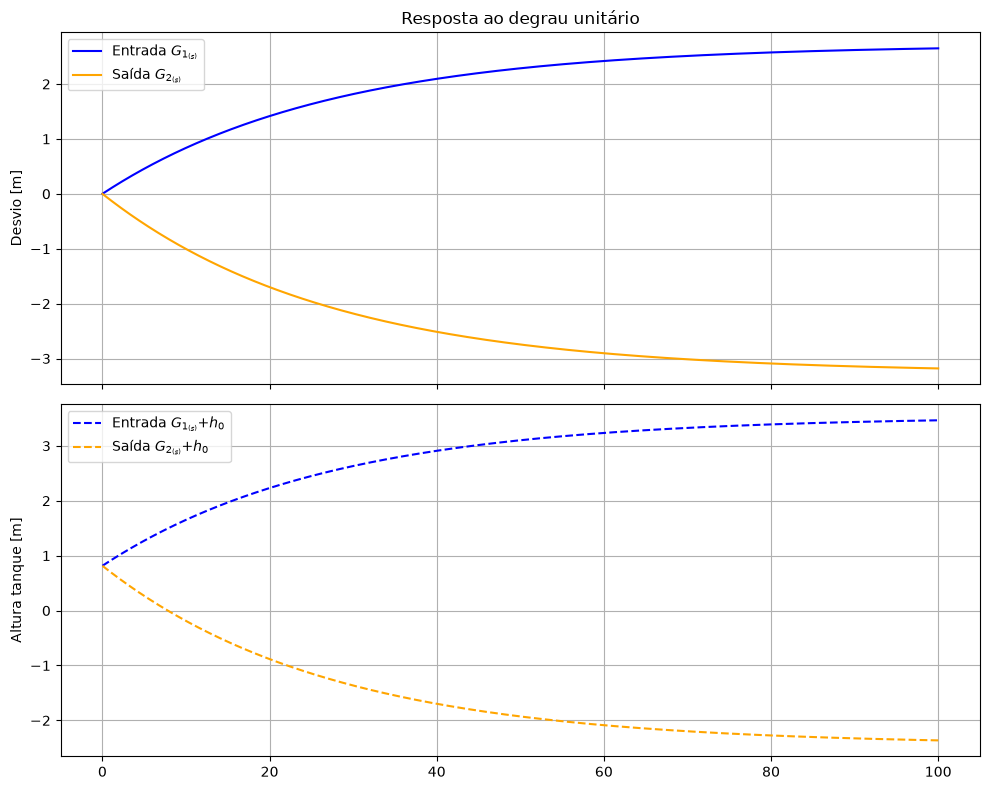

In [8]:
# Resposta ao degrau unitário na válvula de entrada

sys_entrada = G1s
sys_saida = G2s

t = np.linspace(0, 100, 1000)

t, y_in = ct.step_response(sys_entrada, T=t)
t, y_out = ct.step_response(sys_saida, T=t)

y_in_absolute = y_in + h_0
y_out_absolute = y_out + h_0

fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax[0].plot(t, y_in, label=r'Entrada $G_{1_{(s)}}$', color='blue')
ax[0].plot(t, y_out, label=r'Saída $G_{2_{(s)}}$', color='orange')
ax[0].set_title('Resposta ao degrau unitário')
ax[0].set_ylabel('Desvio [m]')
ax[0].legend()
ax[0].grid(True)



ax[1].plot(t, y_in_absolute, label=r'Entrada $G_{1_{(s)}} \plus h_0$', ls='--', color='blue')
ax[1].plot(t, y_out_absolute, label=r'Saída $G_{2_{(s)}} \plus h_0$', ls='--', color='orange')
ax[1].set_ylabel('Altura tanque [m]')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# 2 Premissa adotada -  Controle proporcional
Pressupõe que apenas a válvula de saída está em malha fechada.

$\bar{E}_{(s)} = \bar{H}_{(s)} - \bar{H}_{sp (s)}$

Seja,

$G_{1_(s)} = \frac{2.72}{26.67.s + 1}$

$G_{2_(s)} = \frac{-3.72}{26.67.s + 1}$

$G_c = K_c(\bar{H}_{(s)} - \bar{H}_{sp (s)})$

Então, substituindo $\bar{E}_{(s)}$
$$\bar{H}_{(s)} = \frac{G_{1_(s)}}{1-G_{2_{(s)}} K_c}\bar{A}_{1(s)} + \frac{(-G_{2_(s)})}{1-G_{2_{(s)}} K_c} \bar{A}_{2(s)}$$

Analisando a malha fechada pela Equação (*):
$$\bar{A}_{2(s)} = K_c . \bar{E}_{(s)} =  K_c(\bar{H}_{(s)} - \bar{H}_{sp (s)}) \rightarrow \frac{\partial \bar{A}_{2(s)} }{\partial \bar{H}} > 0 \therefore \textbf{Ação DIRETA}$$

Ou seja, nível acima do setpoint resulta em abertura da válvula de saída pelo algoritmo.

Malha fechada na saída resulta em:
$$\frac{\bar{H}_{(s)}}{\bar{H}_{(sp)}} = \frac{-K_c * G_{2(s)}}{1 -K_c * G_{2(s)}}$$

In [9]:
# Modelo com saída em malha fechada
setpoint = 1.0      # m
Kc = 1.5            # ganho proporcional

desvio = setpoint - h_0

# Ganho controlador proporcional
Gc = -Kc*G2s

sys_closed_loop = ct.feedback(Gc, 1, sign=-1)

t = np.linspace(0, 60, 1000)
_, y_closed_loop = ct.step_response(sys_closed_loop, T=t)

$\textbf{Feedback na biblioteca "Control"}$

Dado que $G_c = -K_c * G_{2(s)}$, a função feedback faz a operação:
$$\frac{G_c}{1 - sinal*(G_c)}$$

Assim, é possível obter:
$$\frac{G_c}{1 + (-1)*(G_c)} = \frac{-K_c * G_{2(s)}}{1 -K_c * G_{2(s)}}$$

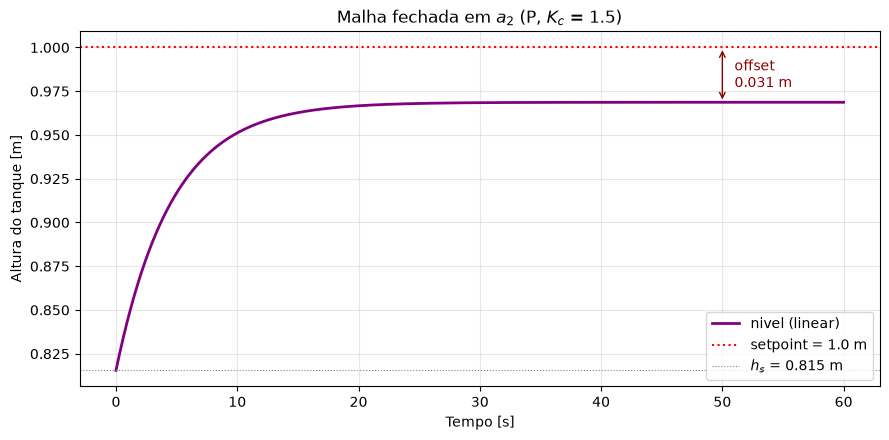

In [10]:
h_bar = y_closed_loop * desvio                 # escala pelo degrau REAL
h_abs = h_0 + h_bar                            # volta para altura absoluta

offset = setpoint - h_abs[-1]

plt.figure(figsize=(9, 4.5))
plt.plot(t, h_abs, color='purple', lw=2, label='nivel (linear)')

plt.axhline(setpoint, color='red', ls=':', label=f'setpoint = {setpoint} m')
plt.axhline(h_0, color='gray', ls=':', lw=.8, label=f'$h_s$ = {h_0:.3f} m')

plt.annotate('', xy=(50, setpoint), xytext=(50, h_abs[-1]),
             arrowprops=dict(arrowstyle='<->', color='darkred'))

plt.text(51, (setpoint+h_abs[-1])/2, f'offset\n{offset:.3f} m',
         color='darkred', va='center')

plt.xlabel('Tempo [s]'); plt.ylabel('Altura do tanque [m]')
plt.title(f'Malha fechada em $a_2$ (P, $K_c$ = {Kc})')
plt.legend(loc='lower right'); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [11]:
Kc_var = [0.5, 1.5 , 2.5, 3.5, 10]

Gc_var = list()

for Kc in Kc_var:
    Gc = -Kc*G2s
    Gc_var.append(Gc)

y_var = list()

for Gc in Gc_var:
    sys_closed = ct.feedback(Gc, 1, sign=-1)
    _, y_closed = ct.step_response(sys_closed, T=t)
    y_var.append(y_closed)

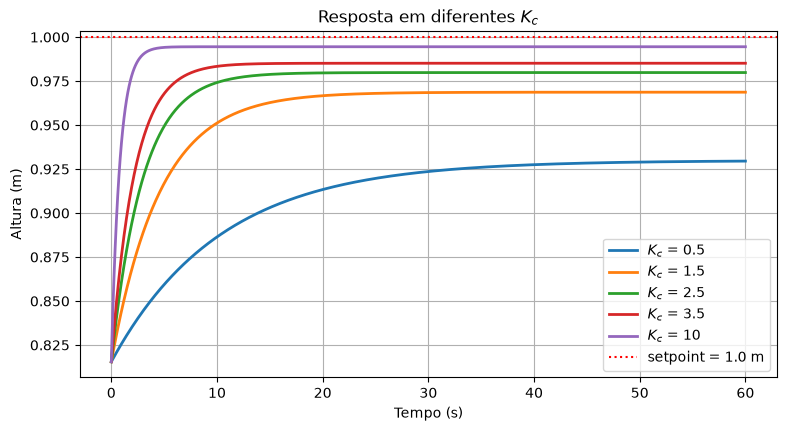

In [12]:
plt.figure(figsize=(9, 4.5))
for i, Kc in enumerate(Kc_var):
    h_bar = y_var[i] * desvio                
    h_abs = h_0 + h_bar       # altura absoluta
    plt.plot(t, h_abs, lw=2, label=f'$K_c$ = {Kc}')

plt.axhline(setpoint, color='red', ls=':', label=f'setpoint = {setpoint} m')

plt.xlabel('Tempo (s)')
plt.ylabel('Altura (m)')
plt.title('Resposta em diferentes $K_c$')
plt.legend()
plt.grid(True)

Notável que independentemente do valor de $K_c$ adotado haverá um offset em relação ao setpoint. Isso é esperado, visto que a limitação do algoritmo proporcional é dependente de um erro para a atuação. Matematicamente se resume a:
$$\bar{A}_{2(s)} = K_c * \bar{E}_{(s)}$$

Para que alcance um valor exato $\bar{E}_{(s)} \rightarrow 0$, visto que as variáveis são positivas e isolando o termo de erro temos:

$$\bar{E}_{(s)} = \frac{\bar{A}_{2(s)}}{K_c}$$

Para haver uma ação do controlador, então $\bar{E}_{(s)} \neq 0$, caso contrário resultaria em um sistema em malha aberta.


In [13]:
setpoint = 1.0
Kc = 1.5
t_step = 10.0
desvio = setpoint - h_0

sys_cl = ct.feedback(-Kc*G2s, 1, sign=-1)

t = np.linspace(0, 100, 1000)

degrau = np.where(t >= t_step, 1.0, 0.0)

# forced_response + um vetor U que você desenha = degrau em qualquer instante.
resp  = ct.forced_response(sys_cl, T=t, U=degrau*desvio)   
h_bar = np.asarray(resp.outputs).reshape(-1)
print(h_bar[-10:])

h_abs = h_0 + h_bar
print(h_abs[-10:])

[0.15319632 0.15319632 0.15319632 0.15319632 0.15319632 0.15319632
 0.15319632 0.15319632 0.15319632 0.15319632]
[0.96869072 0.96869072 0.96869072 0.96869072 0.96869072 0.96869072
 0.96869072 0.96869072 0.96869072 0.96869072]


A linha `resp  = ct.forced_response(sys_cl, T=t, U=degrau*desvio)` manipula o feedback: $$\frac{-K_c * G_{2(s)}}{1 -K_c * G_{2(s)}}$$

E `U` é justamente $\bar{H}_{sp(s)}$ = desvio $\times$ degrau

Então:
$$\text{resp} = \frac{-K_c * G_{2(s)}}{1 -K_c * G_{2(s)}} \cdot \bar{H}_{sp(s)}$$

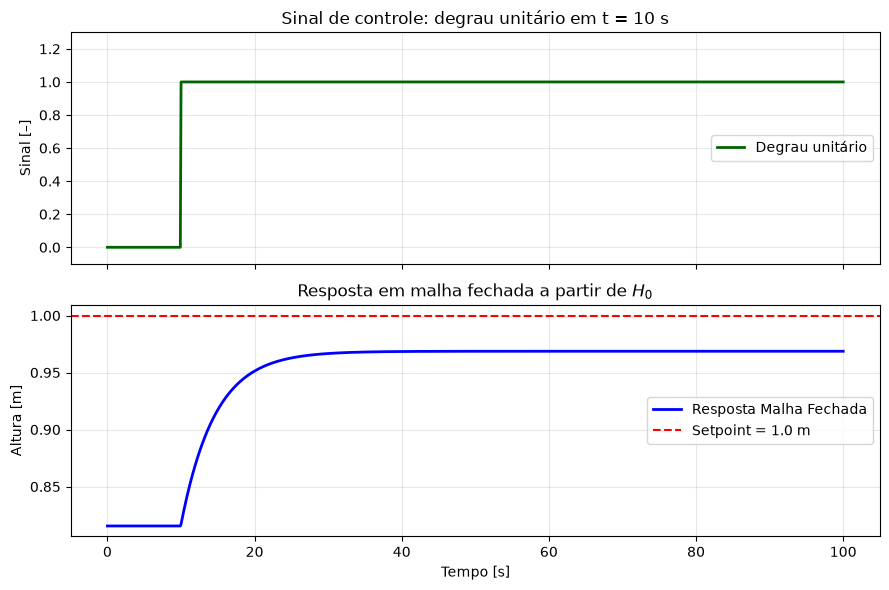

In [14]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax[0].plot(t, degrau, color='darkgreen', lw=2, label='Degrau unitário')
ax[0].set_ylabel('Sinal [–]'); ax[0].set_ylim(-0.1, 1.3)
ax[0].set_title('Sinal de controle: degrau unitário em t = 10 s')
ax[0].legend(loc='right'); ax[0].grid(alpha=.3)

ax[1].plot(t, h_abs, 'b-', lw=2, label='Resposta Malha Fechada')
ax[1].axhline(setpoint, color='r', ls='--', lw=1.5, label=f'Setpoint = {setpoint} m')
ax[1].set_xlabel('Tempo [s]'); ax[1].set_ylabel('Altura [m]')
ax[1].set_title('Resposta em malha fechada a partir de $H_0$')
ax[1].legend(loc='right'); ax[1].grid(alpha=.3)

plt.tight_layout(); plt.show()

# 3 Controle Proporcional+Integral

Sabe-se que:
$$\bar{H}_{(s)} = \bar{G}_{1(s)} \bar{A}_{1(s)} + \bar{G}_{2(s)} \bar{A}_{2(s)}$$

Onde $G_c=K_c \biggl(1 - \frac{1}{\tau_I s} \biggl)$ e $\bar{A}_{2(s)} = G_c \bar{E}_{(s)}$

Logo, 
$$\bar{H}_{(s)} = \frac{\bar{G}_{1(s)}}{1 - \bar{G}_{2(s)} G_c} \bar{A}_{1(s)} + \frac{\bar{G}_{2(s)}}{1 - \bar{G}_{2(s)} G_c} \bar{A}_{1(s)}$$

Denseolvendo o termo $1 - \bar{G}_{2(s)} G_c\ $:

$$1 - \bar{G}_{2(s)} G_c = 1 - \frac{K_2}{\tau s +1} . \frac{K_c (\tau s +1)}{\tau_I s} = \frac{(\tau s +1) \tau_I s - K_2 K_c (\tau_I s +1)}{(\tau s +1)\tau_I s}$$

Onde o denominador gera o seguinte termo de 2ª ordem: $\tau \tau_I s^2 + \tau_I(1-K_2 K_c)s - K_2 K_c$

Assim, para o $\textbf{servo}$ temos:
$$\frac{\bar{H}_{(s)}}{\bar{H}_{sp(s)}} = \frac{- K_2 K_c (\tau_I .s +1)}{\tau \tau_I s^2 + \tau_I(1-K_2 K_c)s - K_2 K_c}$$

E para o $\textbf{regulatório}$ temos:
 $$\frac{\bar{H}_{(s)}}{\bar{A}_{1(s)}}  = \frac{K_1 / (\tau s +1)}{\frac{(\tau s +1) \tau_I s - K_2 K_c (\tau_I s +1)}{(\tau s +1)\tau_I s}} = \frac{K_1 \tau_I s}{\tau \tau_I s^2 + \tau_I(1-K_2 K_c)s - K_2 K_c}$$

In [15]:
Kc = 1.5
sp_bar = setpoint - h_0
u = np.where(t >= 10, sp_bar, 0.0)

TAU_I_01 = 10.0
TAU_I_02 = 25.0

def closed_loop_PI(Gc):
    servo = ct.feedback(-Gc * G2s, 1, sign=-1)
    y_PI = ct.forced_response(servo, T=t, U=u).outputs
    return h_0 + np.asarray(y_PI).reshape(-1)

P = closed_loop_PI(ct.tf([Kc], [1]))
PI1 = closed_loop_PI(ct.tf([Kc*TAU_I_01, Kc], [TAU_I_01, 0]))
PI2 = closed_loop_PI(ct.tf([Kc*TAU_I_02, Kc], [TAU_I_02, 0]))

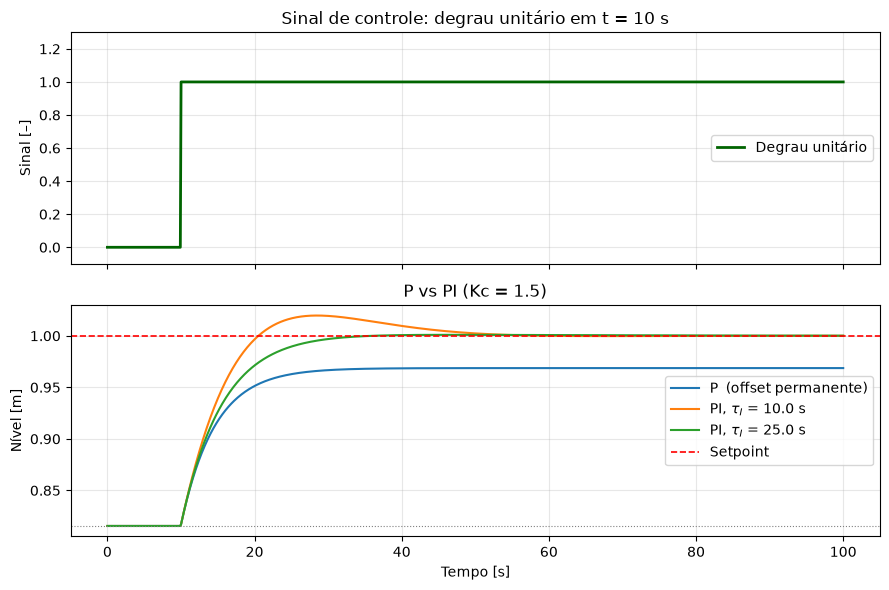

offset P  : 0.0313 m
offset PI1: -0.0000 m
offset PI2: -0.0001 m


In [16]:
fig, ax = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

ax[0].plot(t, degrau, color='darkgreen', lw=2, label='Degrau unitário')
ax[0].set_ylabel('Sinal [–]'); ax[0].set_ylim(-0.1, 1.3)
ax[0].set_title('Sinal de controle: degrau unitário em t = 10 s')
ax[0].legend(loc='right'); ax[0].grid(alpha=.3)

ax[1].plot(t, P,   label='P  (offset permanente)')
ax[1].plot(t, PI1, label=f'PI, $\\tau_I$ = {TAU_I_01} s')
ax[1].plot(t, PI2, label=f'PI, $\\tau_I$ = {TAU_I_02} s')
plt.axhline(setpoint, color='r', ls='--', lw=1.2, label='Setpoint')
plt.axhline(h_0, color='gray', ls=':', lw=.8)
plt.xlabel('Tempo [s]'); plt.ylabel('Nível [m]')
plt.title(f'P vs PI (Kc = {Kc})')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout()
plt.show()
 
print(f"offset P  : {setpoint - P[-1]:.4f} m")
print(f"offset PI1: {setpoint - PI1[-1]:.4f} m")
print(f"offset PI2: {setpoint - PI2[-1]:.4f} m")

# 4 Primário Direto vs. Cascata

A partir do equacionalmento original...
$$(s - K_h) \bar{H}_{(s)} = K_{a_1} \bar{A}_{1(s)} + K_{a_2} \bar{A}_{2(s)}$$

Do balanço do sistema: $F_0 - F_s = A.h$, mas $F_0$ não depende de $a_2, h$

Logo, $\frac{dh}{dt} = \frac{-F_s}{A}$

Seja $f = F_s(a_2 , h)$ onde $\bar{F} = F_s  - F(0)$:

$$\frac{df}{dt} = \frac{\bar{F}}{dt} = \underbrace{\biggl[\frac{\partial F_s}{\partial a_2} \biggl]_s}_{K_{F_a2}} \bar{A}_2 + \underbrace{\biggl[ \frac{\partial F_s}{\partial h} \biggl]_s}_{K_{Fh}} \bar{H}$$

Assim,
$$\bar{F} = K_{Fa_2} \bar{A}_{2(s)} + K_{F_h} \bar{H}_{(s)}$$

Escravo: $\bar{A_2} = G_{c_2} \bar{E}_2 ,\ \bar{E}_2 = \bar{F} - \bar{F}_{sp}$

Mestre:  $\bar{F}_{sp} = G_{c_1} \bar{E}_1,\ \bar{E}_1 = \bar{H} - \bar{H}_{sp}$

Definindo $A_2$ como: $\bar{A}_2 = G_{c_2} (K_{Fa_2} \bar{A}_2 + K_{F_h} \bar{H} - \bar{F}_{sp}) \rightarrow \bar{A}_2 \underbrace{(1 - G_{c_2} K_{Fa_2})}_{\Delta} = G_{c_2}(K_{F_h} \bar{H} - \bar{F}_{sp}) \rightarrow \bar{A}_2 = \biggl( \frac{G_{c_2} (K_{F_h} \bar{H} - \bar{F}_{sp})}{\Delta} \biggl)$

Substituindo $\bar{A}_2$ no equacionamento de balanço:
$$(s - K_h) \bar{H}_{(s)} = K_{a_1} \bar{A}_{1(s)} + K_{a_2} \underbrace{\biggl[ \frac{G_{c_2} (K_{F_h} \bar{H} - \bar{F}_{sp})}{\Delta} \biggl]}_{\bar{A}_{2(s)}}$$

Visto que:
- $K_{Fa_2} = -A . K_{a_2}$
- $K_{F_h} = -A . K_{h}$

Então,

$\biggl(s - K_h - \frac{K_{a_2} G_{c_2} K_{F_h}}{\Delta} \biggl) \bar{H}_{(s)} = K_{a_1} \bar{A}_{1(s)} - \frac{K_{a_2} G_{c_2}}{\Delta} \bar{F}_{sp}$

Adotando $K_{a_2} K_{F_h} \approx K_{F_{a2}} K_{Fh}$

$$s - K_h = \frac{G_{c_2} K_{F_{a2}} K_h}{\Delta} = s - K_h \underbrace{\biggl(1 + \frac{G_{c_2} K_{F_{a2}}}{\Delta} \biggl)}_{\frac{1 + G_{c_2} K_{F_{a2}}}{1 - G_{c_2} K_{F_{a2}}} = \frac{1}{\Delta}}$$

Assim,
$$\biggl(s - \frac{K_h}{\Delta} \bar{H}_{(s)} = K_{a_1} \bar{A}_{1(s)} - \frac{K_{a_2} G_{c_2}}{\Delta} \bar{F}_{sp (s)} \biggl)$$

Dividindo por $\frac{K_h}{\Delta}$:
$$\bar{H}_{(s)} = \frac{K_1^c}{\tau^c s + 1} \bar{A}_{1(s)} + \underbrace{\frac{K_3}{\tau^c s + 1}}_{G_{3(s)}} \bar{F}_{sp(s)}$$

In [17]:
KFa2 = k2 * np.sqrt(2*g*h_0)                     # dFs/da2 |s
KFh  = k2 * a2 * np.sqrt(2*g)/(2*np.sqrt(h_0))   # dFs/dh  |s

Kc2 = 100.0
Gc2 = -Kc2                      # ação REVERSA (oposta à do mestre)

Delta = 1 - Gc2*KFa2
K3    = np.round(-K2*Gc2, 3)    # K3 = -K2 * Gc2
K1_c  = np.round(Delta*K1, 3)


tau_c = np.round(Delta*tau, 3)  # tau^c = Delta * tau

G3s = ct.TransferFunction([K3], [tau_c, 1])

Fechando a malha externa com mestre P ($G_{c1} = K_{c1}$, ação direta):
$$\frac{\bar{H}(s)}{\bar{H}_{sp}(s)} = \frac{-G_{c1}G_3(s)}{1 - G_{c1}G_3(s)}$$

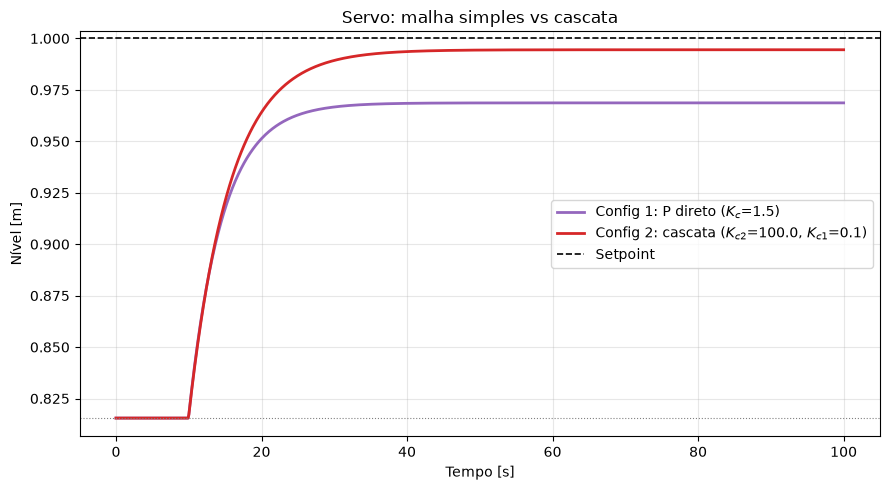

offset Config 1 (P direto)  : 0.0313 m
offset Config 2 (cascata P) : 0.0055 m
razão de offsets: 5.71x menor com cascata


In [18]:
t = np.linspace(0, 100, 1000)
u = np.where(t >= 10, desvio, 0.0)

# Config 1: P direto na abertura, Kc = 1.5
Kc1_malha_simples = 1.5
y1 = ct.forced_response(ct.feedback(-Kc1_malha_simples*G2s, 1, sign=-1), T=t, U=u).outputs
h_cfg1 = h_0 + np.asarray(y1).reshape(-1)

# Config 2: cascata, mestre P Kc1 = 0.1
Kc1_P_master = 0.1
servo_cas_p = ct.feedback(-Kc1_P_master*G3s, 1, sign=-1)
y2 = ct.forced_response(servo_cas_p, T=t, U=u).outputs
h_cfg2 = h_0 + np.asarray(y2).reshape(-1)

plt.figure(figsize=(9, 5))
plt.plot(t, h_cfg1, color='tab:purple', lw=2, label=f'Config 1: P direto ($K_c$={Kc1_malha_simples})')
plt.plot(t, h_cfg2, color='tab:red',    lw=2, label=f'Config 2: cascata ($K_{{c2}}$={Kc2}, $K_{{c1}}$={Kc1_P_master})')
plt.axhline(setpoint, color='k', ls='--', lw=1.2, label='Setpoint')
plt.axhline(h_0, color='gray', ls=':', lw=.8)
plt.xlabel('Tempo [s]'); plt.ylabel('Nível [m]')
plt.title('Servo: malha simples vs cascata'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f'offset Config 1 (P direto)  : {setpoint - h_cfg1[-1]:.4f} m')
print(f'offset Config 2 (cascata P) : {setpoint - h_cfg2[-1]:.4f} m')
print(f'razão de offsets: {(setpoint-h_cfg1[-1])/(setpoint-h_cfg2[-1]):.2f}x menor com cascata')

Fechando a malha externa com mestre P ($G_{c1} = K_{c1}$, ação direta):
$$\frac{\bar{H}(s)}{\bar{H}_{sp}(s)} = \frac{-G_{c1}G_3(s)}{1 - G_{c1}G_3(s)}$$

In [19]:
t = np.linspace(0, 100, 1000)
u = np.where(t >= 10, desvio, 0.0)

Kc1_malha_simples = 1.5     # Config 1: P direto na abertura (PRD), Kc = 1.5

Kc1_P_master = 0.1          # Config 2: cascata, mestre P Kc1 = 0.1

prd_function = lambda Kc: ct.tf([Kc], [1]) 

Kc1_PI_master = 0.1         # Config 3: cascata, mestre PI
TAU_I_MASTER_1 = 10.0
TAU_I_MASTER_2 = 25.0

In [20]:
def closed_loop(Kc, tau_i=None, mode='prd'):
    # controlador: P se tau_i is None, PI caso contrário
    if tau_i is None:
        Gc = ct.tf([Kc], [1])                     # P
    else:
        Gc = ct.tf([Kc*tau_i, Kc], [tau_i, 0])    # PI = Kc*(1 + 1/(tau_i*s))

    # processo visto pelo controlador
    G = G2s if mode == 'prd' else G3s

    servo = ct.feedback(-Gc*G, 1, sign=-1)
    y = ct.forced_response(servo, T=t, U=u).outputs
    return h_0 + np.asarray(y).reshape(-1)

In [21]:
# Config 1 — primário direto, P
h_cfg1 = closed_loop(Kc1_malha_simples, mode='prd')          # Kc=1.5

# Config 2 — cascata, mestre P
h_cfg2 = closed_loop(Kc1_P_master, mode='cas')               # Kc=0.1, sem tau_i

# Config 3 — cascata, mestre PI
h_cfg3a = closed_loop(Kc1_PI_master, TAU_I_MASTER_1, 'cas')  # tau_i=10
h_cfg3b = closed_loop(Kc1_PI_master, TAU_I_MASTER_2, 'cas')  # tau_i=25

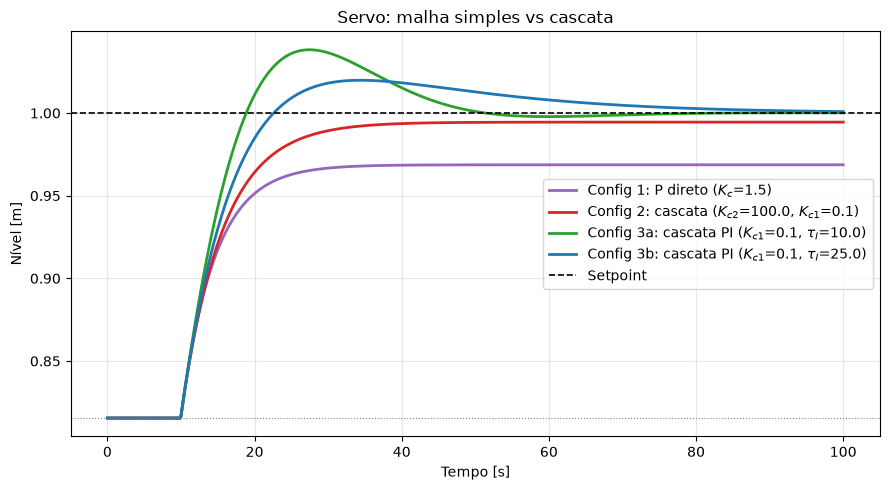

In [22]:
plt.figure(figsize=(9, 5))

plt.plot(t, h_cfg1, color='tab:purple', lw=2, label=f'Config 1: P direto ($K_c$={Kc1_malha_simples})')
plt.plot(t, h_cfg2, color='tab:red',    lw=2, label=f'Config 2: cascata ($K_{{c2}}$={Kc2}, $K_{{c1}}$={Kc1_P_master})')
plt.plot(t, h_cfg3a, color='tab:green',  lw=2, label=f'Config 3a: cascata PI ($K_{{c1}}$={Kc1_PI_master}, $\\tau_I$={TAU_I_MASTER_1})')
plt.plot(t, h_cfg3b, color='tab:blue',   lw=2, label=f'Config 3b: cascata PI ($K_{{c1}}$={Kc1_PI_master}, $\\tau_I$={TAU_I_MASTER_2})')


plt.axhline(setpoint, color='k', ls='--', lw=1.2, label='Setpoint')
plt.axhline(h_0, color='gray', ls=':', lw=.8)
plt.xlabel('Tempo [s]'); plt.ylabel('Nível [m]')
plt.title('Servo: malha simples vs cascata'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [23]:
print(f'offset Config 1 (P ação direta)  : {setpoint - h_cfg1[-1]:.4f} m')
print(f'offset Config 2 (cascata P) : {setpoint - h_cfg2[-1]:.4f} m')
print(f'offset Config 3a (cascata PI, tau_i={TAU_I_MASTER_1}) : {setpoint - h_cfg3a[-1]:.4f} m')
print(f'offset Config 3b (cascata PI, tau_i={TAU_I_MASTER_2}) : {setpoint - h_cfg3b[-1]:.4f} m')

offset Config 1 (P ação direta)  : 0.0313 m
offset Config 2 (cascata P) : 0.0055 m
offset Config 3a (cascata PI, tau_i=10.0) : -0.0001 m
offset Config 3b (cascata PI, tau_i=25.0) : -0.0009 m



Config 1 (PRD, P)
  polos: [-0.21678991+0.j]
  estável? True
    Eigenvalue (pole)       Damping     Frequency
              -0.2168             1        0.2168

Config 2 (cascata, P)
  polos: [-0.17668606+0.j]
  estável? True
    Eigenvalue (pole)       Damping     Frequency
              -0.1767             1        0.1767

Config 3 (cascata, PI)
  polos: [-0.08834303+0.09663631j -0.08834303-0.09663631j]
  estável? True
    Eigenvalue (pole)       Damping     Frequency
  -0.08834  +0.09664j        0.6747        0.1309
  -0.08834  -0.09664j        0.6747        0.1309


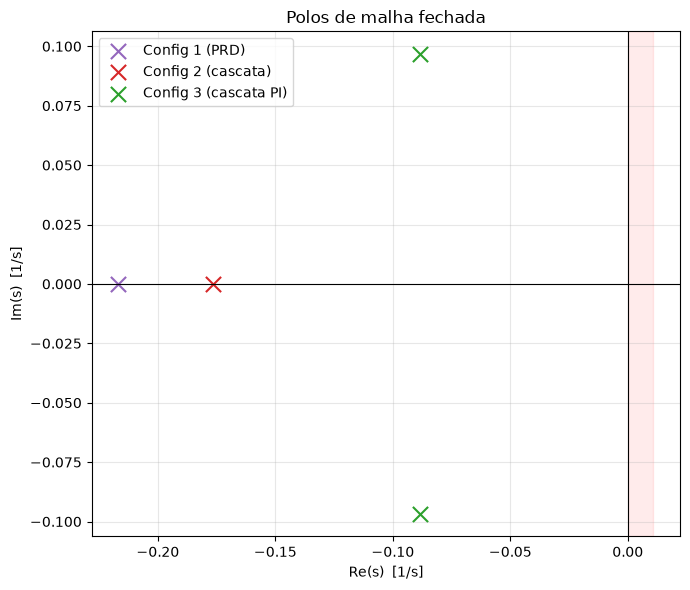

In [24]:
# ---- Análise de polos: Config 1 vs Config 2 ----
cfg1 = ct.feedback(-1.5*G2s, 1, sign=-1)
cfg2 = ct.feedback(-0.1*G3s, 1, sign=-1)
cfg3 = ct.feedback(-0.1*ct.tf([10, 1], [10, 0])*G3s, 1, sign=-1)

for nome, sys in [('Config 1 (PRD, P)', cfg1), ('Config 2 (cascata, P)', cfg2), ('Config 3 (cascata, PI)', cfg3)]:
    print(f'\n{nome}')
    print('  polos:', ct.poles(sys))
    print('  estável?', bool(np.all(np.real(ct.poles(sys)) < 0)))
    ct.damp(sys, doprint=True)

plt.figure(figsize=(7,6))
p1 = ct.poles(cfg1); p2 = ct.poles(cfg2); p3 = ct.poles(cfg3)
plt.scatter(np.real(p1), np.imag(p1), s=120, marker='x', color='tab:purple', label='Config 1 (PRD)')
plt.scatter(np.real(p2), np.imag(p2), s=120, marker='x', color='tab:red',    label='Config 2 (cascata)')
plt.scatter(np.real(p3), np.imag(p3), s=120, marker='x', color='tab:green',  label='Config 3 (cascata PI)')

plt.axvline(0, color='k', lw=.8); plt.axhline(0, color='k', lw=.8)
plt.axvspan(0, plt.xlim()[1] if plt.xlim()[1]>0 else 0.05, alpha=0.08, color='red')  # semiplano instável
plt.xlabel('Re(s)  [1/s]'); plt.ylabel('Im(s)  [1/s]')
plt.title('Polos de malha fechada') # quanto mais à esquerda, mais rápido/estável
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

Para qualquer distúrbio $d$:
$$\bar{F} = K_{F_{a2}} G_{c_2} \bar{F} + d \rightarrow \bar{F}(1-K_{F_{a2}} G_{c_2}) = d \rightarrow \bar{F} = \frac{d}{\Delta}$$

| Escravo | $\Delta$ | vazão que sobra |
|---|---|---|
| primário direto | $1$ | $d$ |
| P | 7 | d/7 |
| PI | $\rightarrow \infty$ | $\rightarrow 0$ |

No modelo *exato*, $F_s = k_2 a_2\sqrt{2gh}$ é uma relação conhecida — nada há a rejeitar. O benefício da cascata só aparece quando essa relação **erra**. Introduzimos uma deriva multiplicativa $\delta$ (por exemplo, desgaste de $k_2$, ou queda de pressão a jusante):

$$F_s = k_2 a_2(1+\delta)\sqrt{2gh} \quad\Rightarrow\quad \left[\frac{\partial F_s}{\partial\delta}\right]_s = k_2 a_{2s}\sqrt{2gh_s} = F_{s,s} = k_1 a_{1s}$$

**Sem cascata:** $\delta$ entra como abertura efetiva $a_{2s}\delta$ — vai direto para o nível.

**Com cascata:** repetindo o Passo 1 com o termo extra, $\;\bar{F}(1 - G_{c2}K_{Fa_2}) = F_{s,s}\delta \Rightarrow \bar{F} = F_{s,s}\delta/\Delta$. 

OCORRE UM **ATENUAÇÃO** POR  $\Delta$ (escravo P) OU TOTAL EM REGIME (escravo PI, pois $|G_{c2}|\to\infty$ quando $s\to0$).

In [26]:
# Cada caso é a função de transferência (ou espaço de estados) H_bar/delta
# na variável de desvio do próprio modo de controle.

Fss = k1*a1                    # dFs/ddelta|s = vazão estacionária
delta_step = 0.30              # 30% de deriva em k2
t2 = np.linspace(0, 300, 3000)
u  = np.where(t2 >= 50, delta_step, 0.0)     # degrau de delta em t=50 s
KFh = k2*a2*np.sqrt(2*g)/(2*np.sqrt(h_0)) 

# ---- (i) SEM cascata: LC-P direto na abertura ----
Kc_reg = 1.5
Hd_sem = ct.minreal(a2*G2s/(1 - Kc_reg*G2s), verbose=False)
h_sem  = np.asarray(ct.forced_response(Hd_sem, T=t2, U=u).outputs).reshape(-1)

# ---- (ii) CASCATA, escravo P ----
Kc1 = 0.1
Hd_P  = ct.tf([-Fss/(A*Delta)], [1, Kc1/A])
h_casP = np.asarray(ct.forced_response(Hd_P, T=t2, U=u).outputs).reshape(-1)

# ---- (iii) CASCATA, escravo PI: espaço de estados [h, I2] ----
Kc2_PI, tauI2 = 20.0, 5.0
beta = Kc2_PI;  den = 1 + beta*KFa2;  gam = KFa2*beta/den
c_h  = KFh - gam*(KFh - Kc1)
A_ss = np.array([[-c_h/A,       gam/(A*tauI2)],
                 [ c_h - Kc1,  -gam/tauI2   ]])

B_ss = np.array([[-(1-gam)/A*Fss],
                 [ (1-gam)*Fss   ]])

C_ss = np.array([[1.0, 0.0]]);  D_ss = np.array([[0.0]])
sys_PI  = ct.ss(A_ss, B_ss, C_ss, D_ss)
h_casPI = np.asarray(ct.forced_response(sys_PI, T=t2, U=u).outputs).reshape(-1)

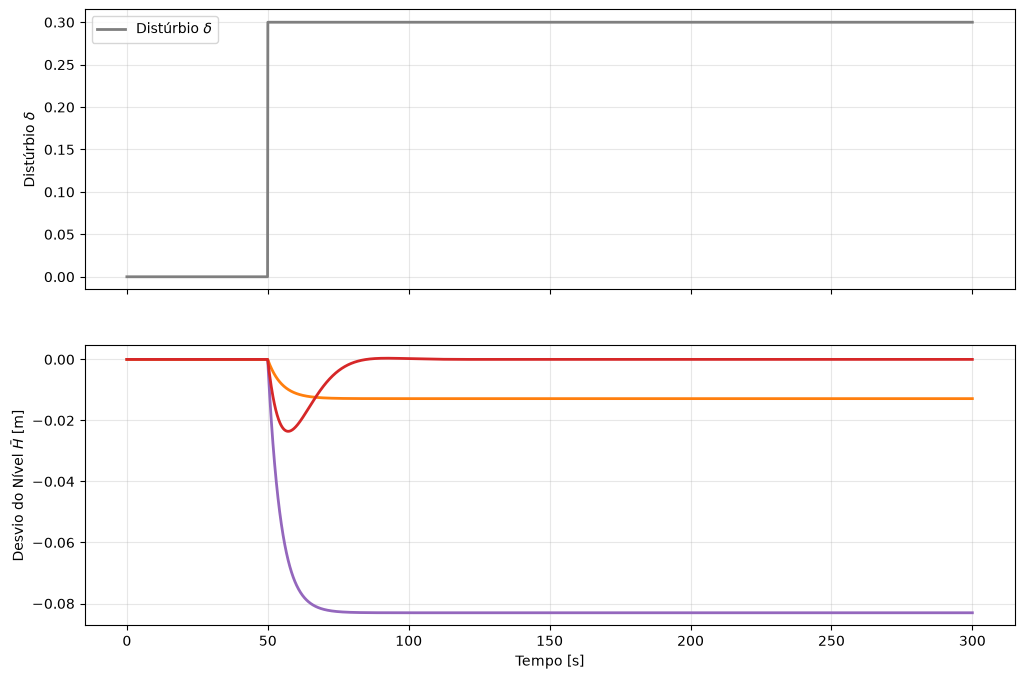

In [48]:
disturbio = np.where(t2 >= 50, delta_step, 0.0)     # degrau de delta em t=50 s

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0] = plt.subplot(2,1,1)
ax[0].plot(t2, disturbio, color='tab:gray', lw=2, label='Distúrbio $\\delta$')
ax[0].set_ylabel('Distúrbio $\\delta$')
ax[0].grid(alpha=.3); ax[0].legend(loc='upper left');

ax[1] = plt.subplot(2,1,2)
ax[1].plot(t2, h_sem,   color='tab:purple', lw=2, label='Sem cascata (P direto)')
ax[1].plot(t2, h_casP,  color='tab:orange', lw=2, label='Cascata, escravo P')
ax[1].plot(t2, h_casPI, color='tab:red',    lw=2, label='Cascata, escravo PI')
ax[1].set_xlabel('Tempo [s]'); ax[1].set_ylabel('Desvio do Nível $\\bar{H}$ [m]')
ax[1].grid(alpha=.3); ax[0].legend(loc='upper left');

In [28]:
print(f'{"caso":<26}{"|desvio| máx [mm]":>18}{"offset final [mm]":>18}')
print('-'*62)
print(f'{"sem cascata":<26}{np.max(np.abs(h_sem))*1e3:>18.2f}{h_sem[-1]*1e3:>18.2f}')
print(f'{"cascata escravo P":<26}{np.max(np.abs(h_casP))*1e3:>18.2f}{h_casP[-1]*1e3:>18.2f}')
print(f'{"cascata escravo PI":<26}{np.max(np.abs(h_casPI))*1e3:>18.2f}{h_casPI[-1]*1e3:>18.4f}')
print('-'*62)
print(f'atenuação de offset (P):  {abs(h_sem[-1]/h_casP[-1]):.2f}x  (previsto: Delta = {Delta:.1f})')
print(f'offset residual (PI): {h_casPI[-1]*1e3:.4f} mm  ->  rejeição estacionária TOTAL')

caso                       |desvio| máx [mm] offset final [mm]
--------------------------------------------------------------
sem cascata                            83.03            -83.03
cascata escravo P                      12.86            -12.86
cascata escravo PI                     23.57            0.0000
--------------------------------------------------------------
atenuação de offset (P):  6.46x  (previsto: Delta = 7.0)
offset residual (PI): 0.0000 mm  ->  rejeição estacionária TOTAL
